In [1]:
#Importing all the Libraries that we need.
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#importing uber dataset.
file_path = 'C:\\Users\\Shubham Raj\\Desktop\\Data Analysis\\Data Set\\uber-raw-data-may14.csv'
data = pd.read_csv(file_path)

In [3]:
#Display the first five rows of Dataset.
print("First five rows of the Dataset:")
print(data.head())

First five rows of the Dataset:
       Date/Time      Lat      Lon    Base  Duration
0  5/1/2014 0:02  40.7521 -73.9914  B02512        62
1  5/1/2014 0:06  40.6965 -73.9715  B02512        66
2  5/1/2014 0:15  40.7464 -73.9838  B02512        44
3  5/1/2014 0:17  40.7463 -74.0011  B02512       115
4  5/1/2014 0:17  40.7594 -73.9734  B02512       104


In [4]:
#Some Basic Informations.
print("Some Basic Information about the Dataset:")
print(data.info())

Some Basic Information about the Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 652435 entries, 0 to 652434
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   Date/Time  652435 non-null  object 
 1   Lat        652435 non-null  float64
 2   Lon        652435 non-null  float64
 3   Base       652435 non-null  object 
 4   Duration   652435 non-null  int64  
dtypes: float64(2), int64(1), object(2)
memory usage: 24.9+ MB
None


In [5]:
#Displaying a comprehensive summary of numerical data
print("Detailed Overview of Numerical Columns:")
print(data.describe())

Detailed Overview of Numerical Columns:
                 Lat            Lon       Duration
count  652435.000000  652435.000000  652435.000000
mean       40.740072     -73.975004      64.972762
std         0.037537       0.054165      32.054572
min        40.106700     -74.929000      10.000000
25%        40.722400     -73.997000      37.000000
50%        40.743300     -73.983900      65.000000
75%        40.761400     -73.968100      93.000000
max        41.322500     -72.180100     120.000000


In [6]:
#Checking for the presence of missing values in each column.
print("Missing values in each column:")
print(data.isnull().sum())

Missing values in each column:
Date/Time    0
Lat          0
Lon          0
Base         0
Duration     0
dtype: int64


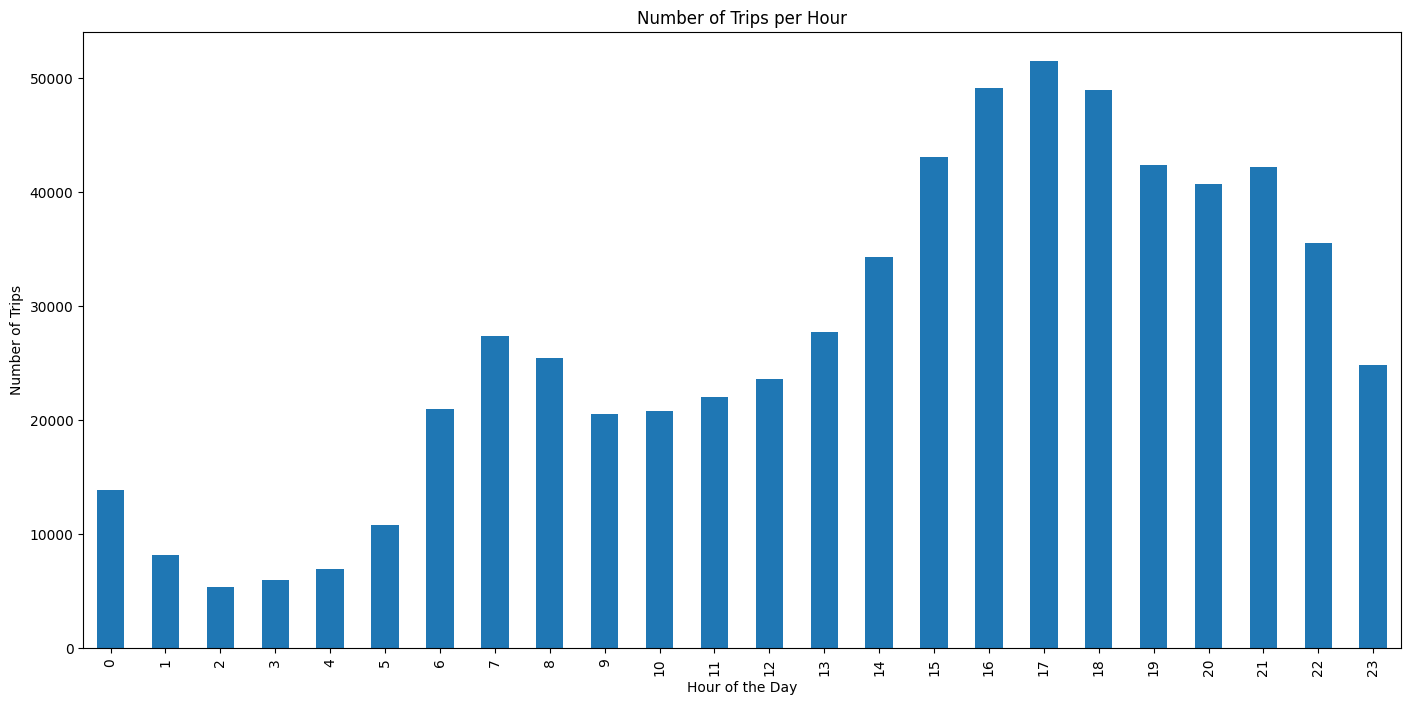

In [7]:
#Covert the 'Date/Time' column to datetime format.
data['Date/Time'] = pd.to_datetime(data['Date/Time'])

#Extract hour and day of the week from the'Date/Time' column.
data['Hour'] = data['Date/Time'].dt.hour
data['DayOfWeek'] = data['Date/Time'].dt.dayofweek

#Plot the number of trips per hour.
plt.figure(figsize=(17,8))
data['Hour'].value_counts().sort_index().plot(kind='bar')
plt.title('Number of Trips per Hour')
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Trips')
plt.show()

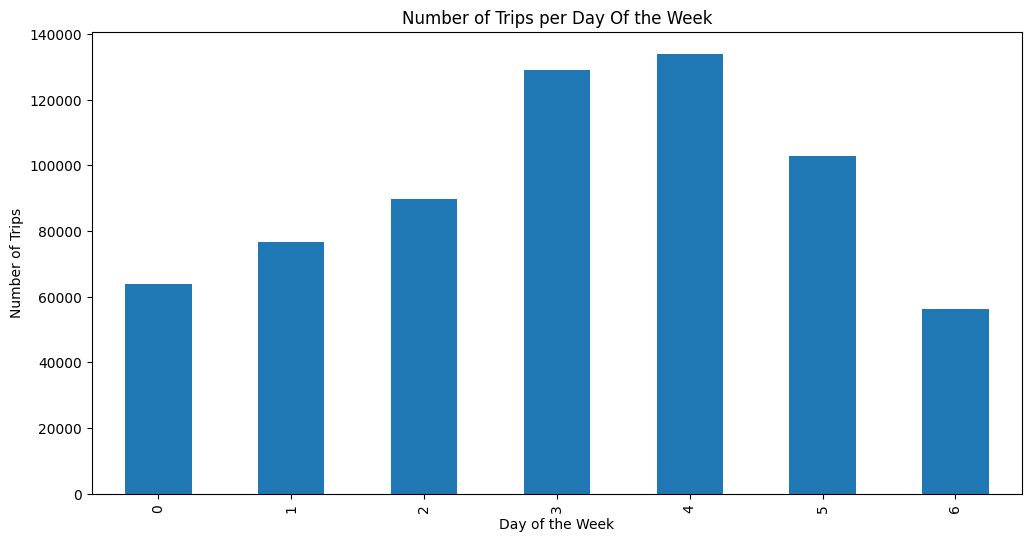

In [8]:
#Plot the number of trips per day of the week.
plt.figure(figsize=(12, 6))
data['DayOfWeek'].value_counts().sort_index().plot(kind='bar')
plt.title('Number of Trips per Day Of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Number of Trips')
plt.show()

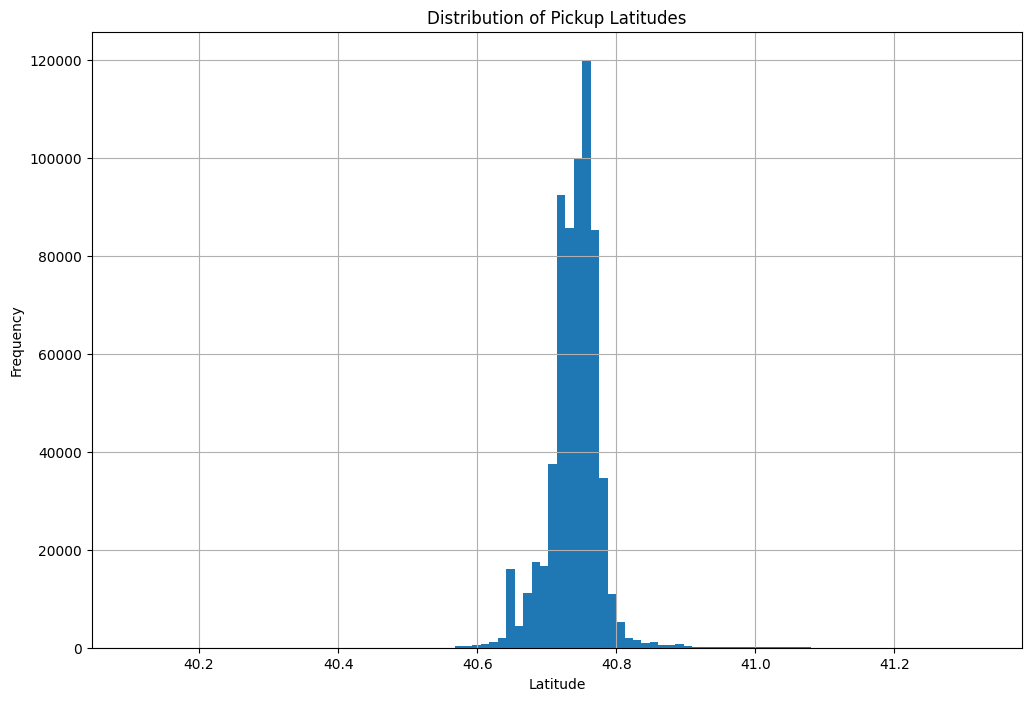

In [9]:
#Plot the most common Pickup Locations.
plt.figure(figsize=(12, 8))
data['Lat'].hist(bins=100)
plt.title('Distribution of Pickup Latitudes')
plt.xlabel('Latitude')
plt.ylabel('Frequency')
plt.show()

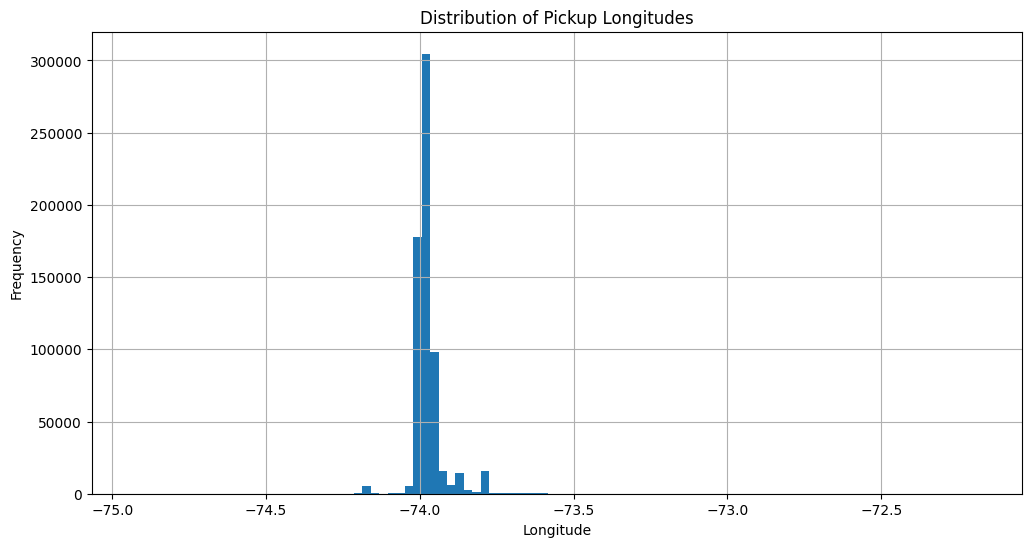

In [10]:
plt.figure(figsize=(12, 6))
data['Lon'].hist(bins=100)
plt.title('Distribution of Pickup Longitudes')
plt.xlabel('Longitude')
plt.ylabel('Frequency')
plt.show()

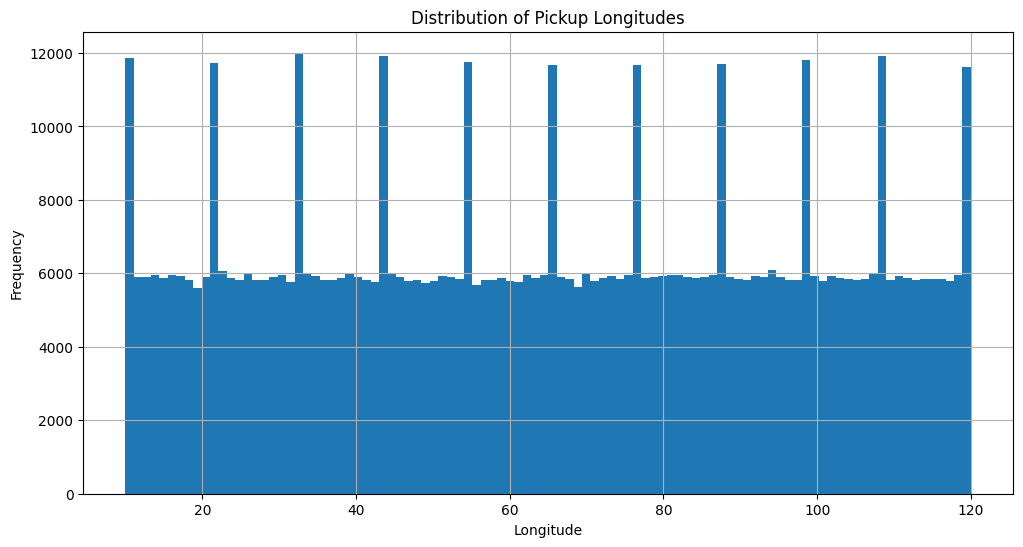

In [11]:
#Assuming there's a 'Duration' column in the dataset.
plt.figure(figsize=(12,6))
data['Duration'].hist(bins=100)
plt.title('Distribution of Pickup Longitudes')
plt.xlabel('Longitude')
plt.ylabel('Frequency')
plt.show()

In [12]:
#Summary statistics for trip durations
print('Summary statistics for trip durations:\n')
print(data['Duration'].describe())

Summary statistics for trip durations:

count    652435.000000
mean         64.972762
std          32.054572
min          10.000000
25%          37.000000
50%          65.000000
75%          93.000000
max         120.000000
Name: Duration, dtype: float64


In [13]:
#Crosstab: Duration by Hour of the Day
duration_by_hour = pd.crosstab(data['Hour'], data['Duration'])
print("Duration by Hour of the Day:\n")
print(duration_by_hour)

Duration by Hour of the Day:

Duration  10   11   12   13   14   15   16   17   18   19   ...  111  112  \
Hour                                                        ...             
0         125  126  139  139  117  127  129  132  114  126  ...  129  126   
1          70   74   72   82   73   83   73   58   68   64  ...   79   74   
2          56   50   43   58   50   61   56   43   47   53  ...   52   57   
3          48   44   50   48   39   61   63   57   48   48  ...   61   54   
4          53   64   60   70   65   71   62   61   62   59  ...   76   66   
5         115   96   93   79   93   78  112   96  104   82  ...  100  106   
6         168  197  185  180  202  191  180  181  166  179  ...  194  198   
7         245  240  247  260  268  294  232  244  249  236  ...  254  271   
8         229  234  235  241  245  227  244  257  215  196  ...  225  217   
9         186  175  181  196  176  204  172  187  181  174  ...  182  201   
10        173  188  180  191  201  180  183  1

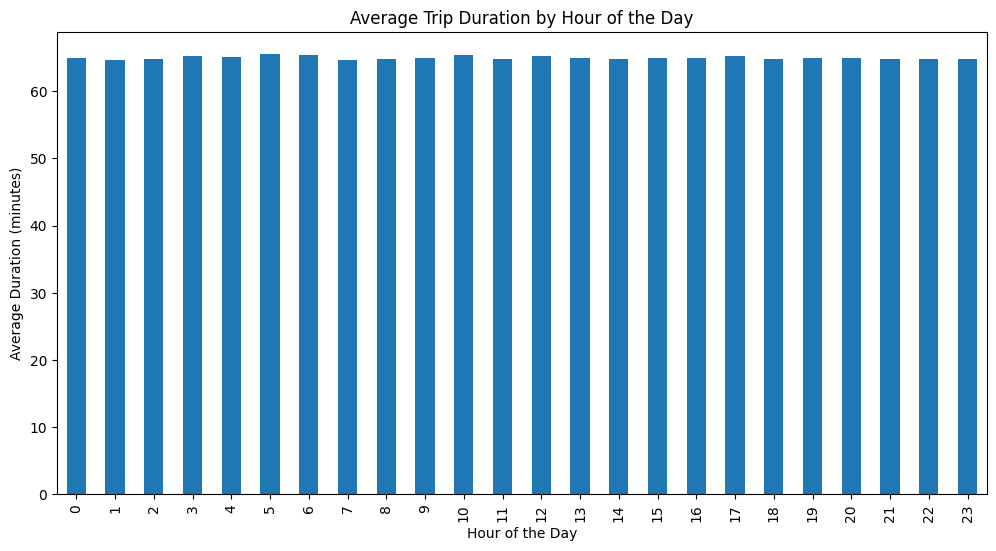

In [14]:
#Average duration by hour of the day
avg_duration_by_hour = data.groupby('Hour')['Duration'].mean()
plt.figure(figsize=(12, 6))
avg_duration_by_hour.plot(kind='bar')
plt.title('Average Trip Duration by Hour of the Day')
plt.xlabel('Hour of the Day')
plt.ylabel('Average Duration (minutes)')
plt.show()

In [15]:
#Crosstab: Duration by Day of the Week.
duration_by_day = pd.crosstab(data['DayOfWeek'], data['Duration'])
print('Duration by Day of the Week:\n')
print(duration_by_day)

Duration by Day of the Week:

Duration    10    11    12    13    14    15    16    17    18    19   ...  \
DayOfWeek                                                              ...   
0           537   624   580   586   611   626   588   600   520   537  ...   
1           706   714   675   674   731   645   734   723   697   664  ...   
2           786   794   836   818   821   785   840   830   845   808  ...   
3          1142  1186  1142  1099  1159  1210  1138  1140  1182  1134  ...   
4          1215  1201  1215  1244  1206  1151  1166  1236  1164  1136  ...   
5           934   985   954   936   904   935   978   922   902   864  ...   
6           518   536   498   534   524   518   500   491   514   471  ...   

Duration    111   112   113   114   115   116   117   118   119   120  
DayOfWeek                                                              
0           589   564   597   565   587   582   575   587   556   572  
1           673   698   686   711   704   698   706

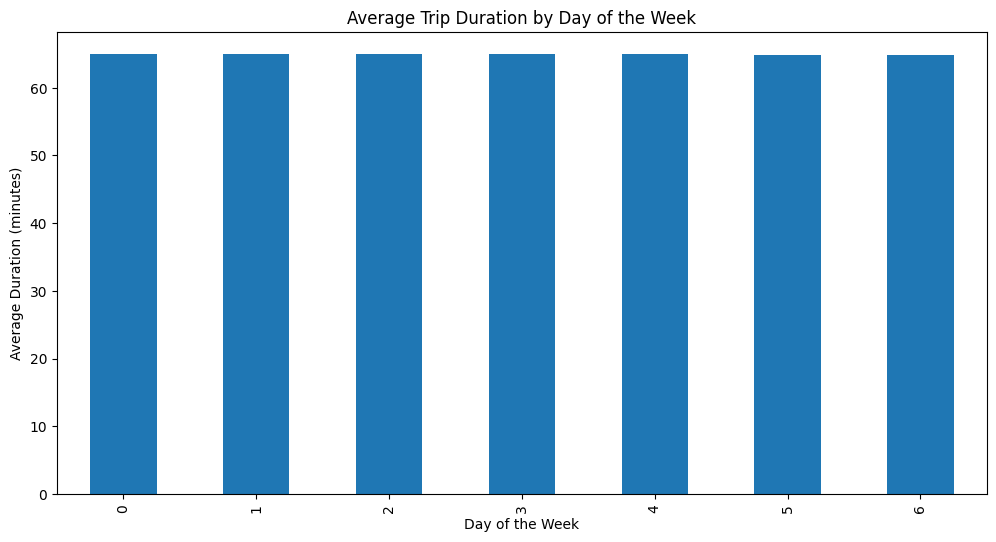

In [16]:
#Average duration by day of the Week.
avg_duration_by_day = data.groupby('DayOfWeek')['Duration'].mean()
plt.figure(figsize=(12, 6))
avg_duration_by_day.plot(kind='bar')
plt.title('Average Trip Duration by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Average Duration (minutes)')
plt.show()

C:\Users\Shubham Raj\AppData\Local\Temp\ipykernel_13680\2633316885.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_duration_by_location = data.groupby(['LatBin', 'LonBin'])['Duration'].mean().unstack()


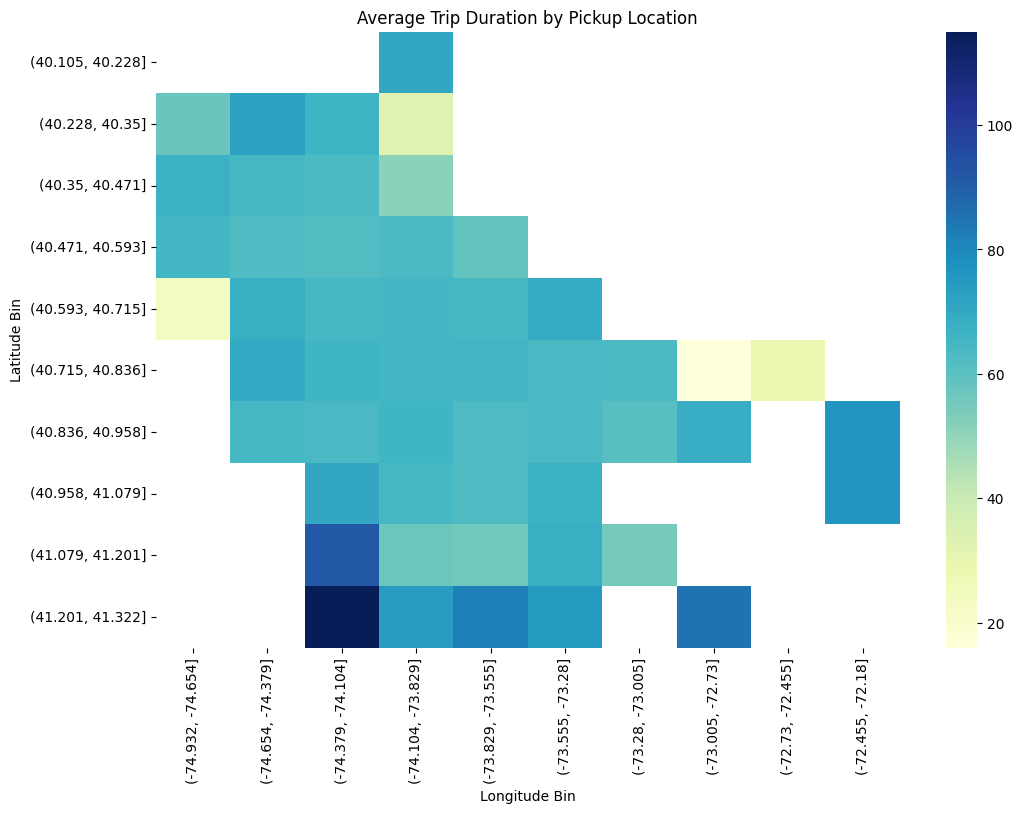

In [17]:
#Assuming 'Lat' and 'Lon' are pickup Locations.

#Binning the Latitudes and Longitudes for more granular analysis
data['LatBin'] = pd.cut(data['Lat'], bins=10)
data['LonBin'] = pd.cut(data['Lon'], bins=10)

#Average duration by pickup Location.
avg_duration_by_location = data.groupby(['LatBin', 'LonBin'])['Duration'].mean().unstack()
plt.figure(figsize=(12, 8))
plt.title('Average Trip Duration by Pickup Location')
sns.heatmap(avg_duration_by_location, cmap="YlGnBu")
plt.xlabel('Longitude Bin')
plt.ylabel('Latitude Bin')
plt.show()